# pyDySP demo

This notebook demonstrates the core functionality of **pyDySP** using example datasets.

We will:
- Load experimental tests from different file formats.
- Explore channels and metadata.
- Apply basic processing (drift correction, filtering, baseline, trimming).
- Compute spectra (Fourier, Welch), Arias intensity and response spectra.
- Work with multi-channel tests (batch processing, plotting grids).
- Perform simple cross-channel analysis (cross-spectrum, transfer function, time delay).
- Generate a channel health report.
- Export processed data back to CSV.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import pydysp

print("pyDySP version:", pydysp.__version__)

pyDySP version: 0.2.0


## 1. Loading example datasets

Demo files are available under `data`

In [2]:
# Update these paths to your local demo files

sofsi_path = "../data/demo_sofsi.mat"
equals_path = "../data/demo_equals.mat"
csv_path = "../data/demo_signals.csv"

test_sofsi = pydysp.Test.from_sofsi_mat(sofsi_path, name="SoFSI demo")
test_equals = pydysp.Test.from_equals_mat(equals_path, name="EQUALS demo")
test_csv = pydysp.Test.from_csv(csv_path, name="CSV demo")

## 2. Exploring a `Test`: channels, metadata, basic info

A `Test` is a collection of `Channel` objects. Each channel has:

- A user-facing name (`name_user`) and an input-file name (`name_input`).
- Physical quantity (e.g. acceleration, displacement) and units.
- Tags and arbitrary metadata.

You can inspect the test with `.info()` and access channels by index or by name.

In [3]:
# Pick one test to explore in more detail
test = test_sofsi  # or test_equals / test_csv

print(test.info())

# Access by index
ch0 = test[0]
print("\n\n\nFirst channel:\n")
print(ch0.info())

# Access by name (update the name to a valid one from test.info())
example_name = ch0.name_user or ch0.name_input
ch_named = test[example_name]
print("\n\n\nChannel by name:\n")
print(ch_named.info())

# Show tags and metadata
ch_named.tags, ch_named.meta

Test: SoFSI demo
  Source file : ../data/demo_sofsi.mat
  Timestamp   : 28/11/2025 14:30:00
  Channels    : 3
  Timesteps   : 200
  Duration    : 1.99 s
  Sampling    : dt=0.01 s, fs=100 Hz
  Test tags   : sofsi
  Meta keys   : sofsi_file_header

|   idx | name_user   | name_input   | quantity   | units   | tags   |
|-------|-------------|--------------|------------|---------|--------|
|     0 | CH1_demo    | CH1_demo     | -          | V       | -      |
|     1 | CH2_demo    | CH2_demo     | -          | V       | -      |
|     2 | CH3_demo    | CH3_demo     | -          | V       | -      |



First channel:

Channel: CH1_demo
-----------------
Length: 200 samples
Sampling frequency: fs = 100 Hz
Timestep: dt = 0.01 s
Start time: t0 = 0.0 s

Physical meaning & calibration:
  Units: V
  Raw units: V

Naming / labels:
  Input name: CH1_demo
  User name: CH1_demo
  Legend label: CH1_demo
  Axis label: CH1_demo [V]

Metadata:
  max_level: 10.0
  correction: none



Channel by name:

Cha

(set(), {'max_level': 10.0, 'correction': 'none'})

## 3. Working with a single `Channel`

We now focus on a single channel that represents an acceleration time history. Processing in pyDySP is **non-destructive**: the raw data are stored, and processing is applied on-the-fly via `.processed()`.

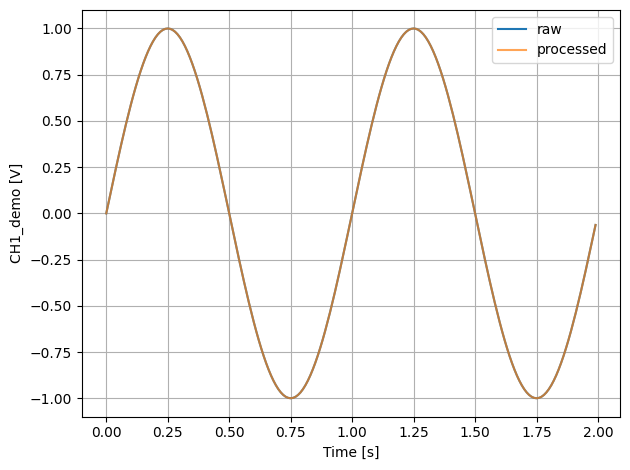

In [4]:
# Select a representative accelerometer channel
acc = ch_named  # ensure this is an acceleration channel from the chosen test

t_raw = acc.time
y_raw = acc.data

t_proc, y_proc = acc.processed()

fig, ax = plt.subplots()
ax.plot(t_raw, y_raw, label="raw")
ax.plot(t_proc, y_proc, label="processed", alpha=0.7)
ax.set_xlabel("Time [s]")
ax.set_ylabel(acc.label_axis)
ax.legend()
ax.grid(True)
fig.tight_layout()

### 3.1 Drift correction, filtering and baseline removal

We apply a sequence of simple processing steps to the selected channel:

1. **Drift correction** – remove mean over the first N samples.
2. **High-pass filtering** – remove very low frequencies.
3. **Baseline correction** – remove linear trend.

Each step returns a **new** `Channel` instance.

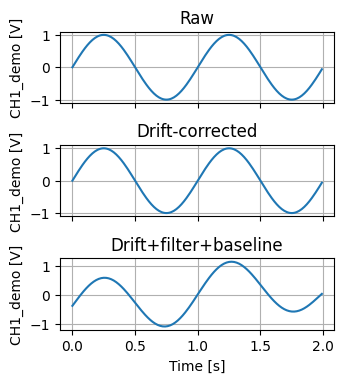

In [5]:
acc_drift = acc.drift_corrected(points=200)
acc_filt = acc_drift.filtered(btype="highpass", fc=0.5, order=2)
acc_base = acc_filt.baseline_corrected(type="linear")

fig, axes = plt.subplots(3, 1, sharex=True, figsize=(9 / 2.54, 10 / 2.54))
for ax, ch, title in zip(
    axes,
    [acc, acc_drift, acc_base],
    ["Raw", "Drift-corrected", "Drift+filter+baseline"],
):
    t, y = ch.processed()
    ax.plot(t, y)
    ax.set_ylabel(ch.label_axis)
    ax.set_title(title)
    ax.grid(True)
axes[-1].set_xlabel("Time [s]")
fig.tight_layout()

### 3.2 Fourier and Welch spectra

We compute and plot:

- the Fourier amplitude spectrum, and
- the Welch power spectral density (PSD).

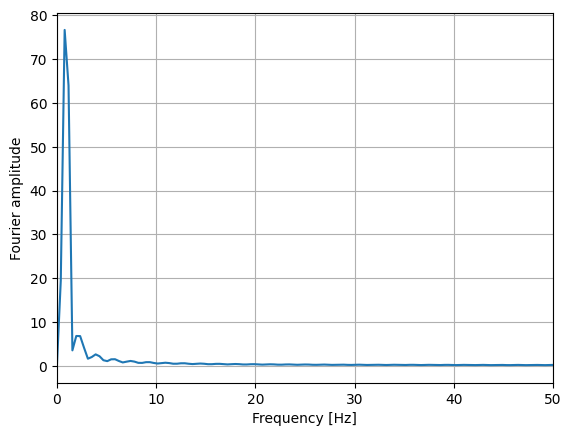

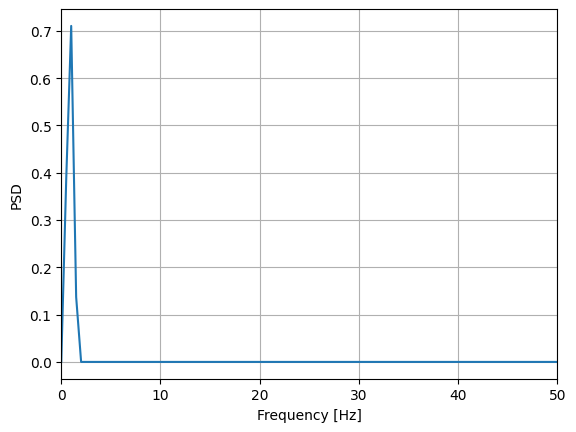

Fourier peak (f, amp): (0.78125, 76.65210707158712)
Welch peak (f, psd):  (1.0, 0.7104072859437375)


In [6]:
fspec = acc_base.fourier()
pspec = acc_base.welch_psd()

fig, ax = plt.subplots()
fspec.plot(ax=ax, fmax=50.0)
plt.show()

fig, ax = plt.subplots()
pspec.plot(ax=ax, fmax=50.0)
plt.show()

print("Fourier peak (f, amp):", fspec.peak())
print("Welch peak (f, psd): ", pspec.peak())

## 4. Arias intensity & automatic trimming

We compute the Arias intensity (Husid curve) of the processed channel and use it to automatically select the strong-motion portion of the record (e.g. 5–95% Arias intensity).

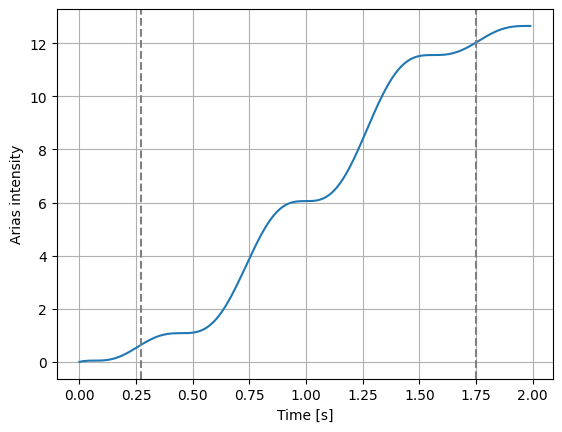

Original duration: 1.99
Trimmed duration:  1.99


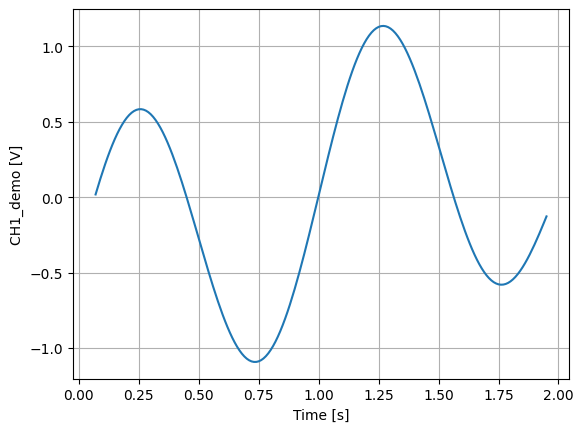

In [7]:
arias_res = acc_base.arias_intensity()
fig, ax = plt.subplots()
arias_res.plot(ax=ax, show_window=True)
plt.show()

acc_trimmed = acc_base.trim_by_arias(
    lower=0.05, upper=0.95, buffer_before=0.2, buffer_after=0.2
)
print("Original duration:", acc_base.duration)
print("Trimmed duration: ", acc_trimmed.duration)

fig, ax = plt.subplots()
acc_trimmed.plot(ax=ax)
plt.show()

## 5. Multi-channel processing at `Test` level

We now perform similar operations for all channels of a `Test` using its batch-processing methods:

- `drift_corrected`
- `filtered`
- `baseline_corrected`
- `trimmed_by_arias`

Trimming is based on a **reference channel**, and the same time window is applied to all selected channels.

In [8]:
# Work with the SoFSI test by default
test0 = test_sofsi

test_proc = (
    test0.drift_corrected(points=200)
    .filtered(btype="highpass", fc=0.5, order=2)
    .baseline_corrected(type="linear")
)

# Use the first channel as reference for Arias trimming by default
ref_name = test_proc[0].name_user or test_proc[0].name_input
test_trimmed = test_proc.trimmed_by_arias(ref=ref_name, lower=0.05, upper=0.95)

print("Original duration:", test0.duration)
print("Processed duration:", test_proc.duration)
print("Trimmed duration:  ", test_trimmed.duration)

Original duration: 1.99
Processed duration: 1.99
Trimmed duration:   1.48


## 6. Test-level plotting: `plot_channels` & `plot_grid`

pyDySP provides convenience methods for plotting multiple channels:

- `plot_channels(selector=..., ncols=...)` to arrange channels automatically.
- `plot_grid(layout=...)` for fully custom subplot layouts.


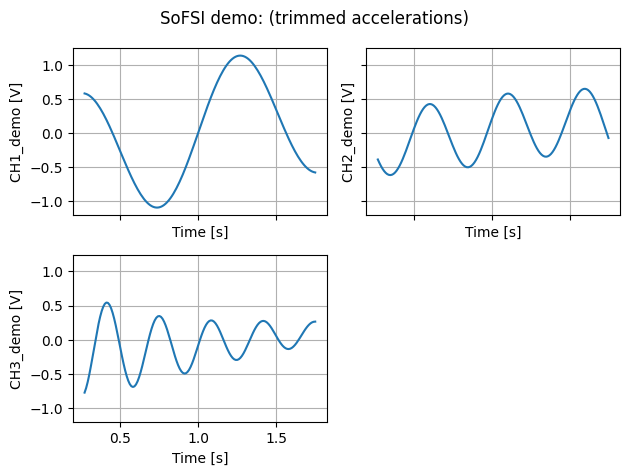

In [9]:
# Simple multi-channel time-history plot
fig, axes = test_trimmed.plot_channels(
    selector=None,  # all channels
    ncols=2,
    plot_type="timehistory",
    title_suffix="(trimmed accelerations)",
)
plt.show()

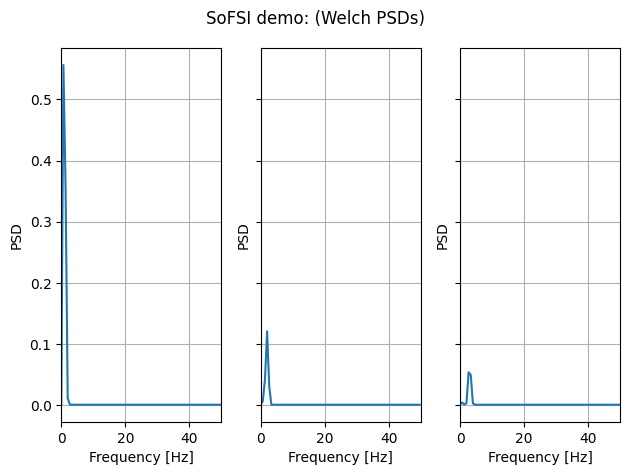

In [10]:
# Custom layout using plot_grid
names = [ch.name_user or ch.name_input for ch in test_trimmed.channels]
layout = [names]  # single row with all channels

fig, axes = test_trimmed.plot_grid(
    layout=layout,
    plot_type="psd",
    title_suffix="(Welch PSDs)",
)
plt.show()

## 7. Cross-channel analysis: cross-spectrum, transfer function & time delay

If your test includes a clear input and response channel (e.g. shaker input and structural response), you can compute:

- the **cross-spectrum** `G_yx`,
- the **transfer function** (H1 or H2 estimator), and
- an approximate **time delay** between signals.

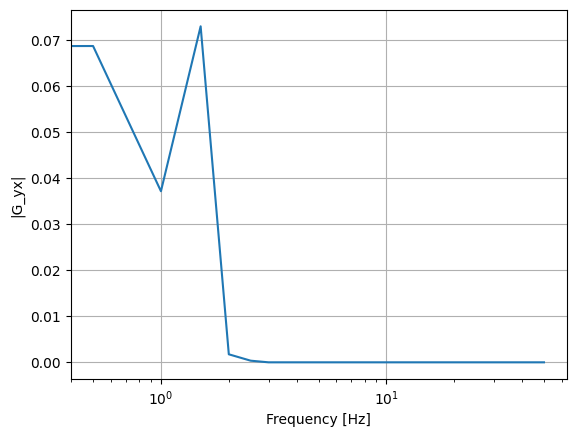

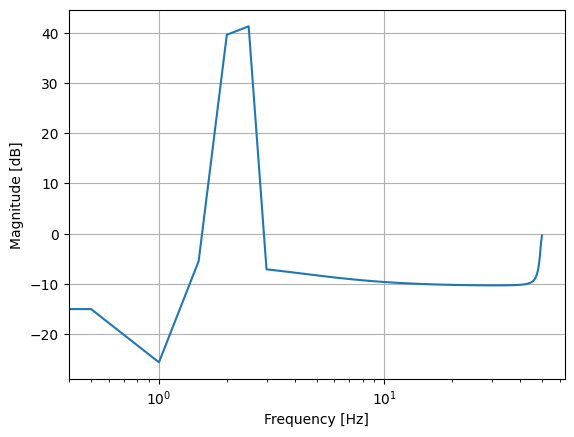

Estimated time delay (output relative to input): 1.28 s


In [11]:
# For illustration we just use the first two channels as 'input' and 'output'.
# Replace these names with appropriate ones for your data.
input_ch = test_proc[0]
output_ch = test_proc[1] if test_proc.n_channels > 1 else test_proc[0]

f_csd, G_yx = test_proc.cross_spectrum(input_ch, output_ch)
fig, ax = plt.subplots()
ax.semilogx(f_csd, np.abs(G_yx))
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("|G_yx|")
ax.grid(True)
plt.show()

f_tf, H1 = test_proc.transfer_function(input_ch, output_ch, kind="H1")
fig, ax = plt.subplots()
ax.semilogx(f_tf, 20 * np.log10(np.abs(H1)))
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("Magnitude [dB]")
ax.grid(True)
plt.show()

delay = test_proc.time_delay(input_ch, output_ch)
print("Estimated time delay (output relative to input):", delay, "s")

## 8. Response spectra from experimental records

We can compute a linear-elastic response spectrum from an accelerogram using `Channel.response_spectrum`, which returns a `ResponseSpectrum` object.

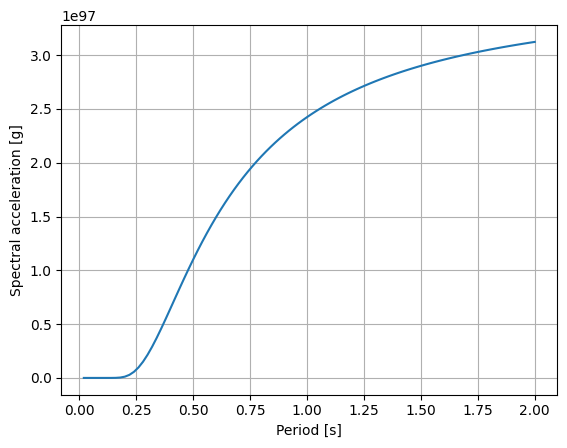

Spectrum peak (T, Sa): (2.0, 3.1230013464295234e+97)


In [12]:
periods = np.linspace(0.02, 2.0, 100)
rs = acc_trimmed.response_spectrum(periods, ksi=0.05)

fig, ax = plt.subplots()
rs.plot(ax=ax, y="Sa")
plt.show()

print("Spectrum peak (T, Sa):", rs.peak())

## 9. Channel health report

The `channel_health` method provides a quick diagnostic of each channel, including:

- peak amplitude,
- RMS level,
- crest factor,
- estimated SNR (based on pre-event noise window), and
- a simple status label (e.g. dead, noise, weak response, ok).

In [13]:
print(test_proc.channel_health())

|   idx | name     |   peak |   rms |   crest |   t_start |   t_end |   dur | rms_pre   | snr_pre   | status        |
|-------|----------|--------|-------|---------|-----------|---------|-------|-----------|-----------|---------------|
|     0 | CH1_demo |   1.14 | 0.641 |    1.77 |         0 |    1.96 |  1.96 | -         | -         | noise         |
|     1 | CH2_demo |  0.649 | 0.372 |    1.74 |      0.01 |    1.99 |  1.98 | 0.0152    | 24.5      | weak response |
|     2 | CH3_demo |  0.963 | 0.366 |    2.63 |         0 |    1.99 |  1.99 | -         | -         | weak response |


## 10. Saving processed data to CSV and reloading

Finally, we can export a processed and trimmed test to CSV and load it back into a new `Test`.

In [14]:
output_csv = "../data/processed_demo.csv"
test_trimmed.to_csv(output_csv, overwrite=True)

test_from_csv = pydysp.Test.from_csv(output_csv, name="ProcessedFromCSV")
print(test_from_csv.info())

Test: ProcessedFromCSV
  Source file : ../data/processed_demo.csv
  Channels    : 3
  Timesteps   : 200
  Duration    : 1.99 s
  Sampling    : dt=0.01 s, fs=100 Hz
  Test tags   : csv
  Meta keys   : csv_header, csv_n_channels, csv_n_samples

|   idx | name_user    | name_input   | quantity   | units   | tags   |
|-------|--------------|--------------|------------|---------|--------|
|     0 | CH1_demo [V] | CH1_demo [V] | -          | -       | -      |
|     1 | CH2_demo [V] | CH2_demo [V] | -          | -       | -      |
|     2 | CH3_demo [V] | CH3_demo [V] | -          | -       | -      |


## 11. Optional: EMA model (if `sdypy` is installed)

If you have [`sdypy`](https://github.com/soil-structure-interaction-lab/sdypy) installed, you can build an `EMA.Model` directly from frequency-response functions computed via pyDySP.

In [15]:
try:
    ema_model = test_proc.ema_model(
        input=input_ch,
        outputs=[output_ch],
        kind="H1",
        lower=1.0,
        upper=50.0,
    )
    print(ema_model)
except ImportError as e:
    print("sdypy not installed; skipping EMA example.")

## 12. Summary & recipes

In this notebook we saw how to:

- Load experimental tests from SoFSI, EQUALS and CSV formats.
- Inspect channels, metadata and basic test information.
- Apply drift correction, filtering, baseline removal and trimming.
- Compute Fourier and Welch spectra, Arias intensity and response spectra.
- Process multiple channels at `Test` level and produce clean plots.
- Perform cross-channel analysis (cross-spectrum, transfer function, time delay).
- Generate a simple channel health report.
- Export processed data back to CSV.

You can now adapt this workflow to your own experimental datasets and integrate it into your analysis notebooks and reports.